# FoodSure AI — Modality Comparison and Multimodal Fusion

## AI-Based Turmeric Adulteration Detection & Quantification

This notebook investigates whether combining multiple data modalities can
improve turmeric adulteration detection and estimation.

The FoodSure AI dataset contains three complementary modalities:

1. Color measurements
2. FTIR spectroscopy
3. EfficientNet-B0 image features

Previous experiments evaluated each modality independently.

This notebook extends those experiments by comparing individual modalities
with pairwise and full multimodal feature fusion.

### Research Questions

1. How does each modality perform independently?
2. Does combining two modalities improve prediction?
3. Does combining all three modalities provide additional information?
4. Which modality combinations are useful for adulteration classification
   and regression?

### Fusion Strategies

The following combinations will be investigated:

- Color + FTIR
- Color + Image
- FTIR + Image
- Color + FTIR + Image

### Important Experimental Principle

All modalities use the same sample-level train/test split established
during preprocessing.

No new random split will be created in this notebook.

The test set will only be used for final evaluation and will not be used
for model fitting or tuning.

The objective is to determine whether complementary information from
different modalities improves predictive performance.

## 2. Load Preprocessed Data

The leakage-safe preprocessed representations generated in Notebook 3 are
loaded for the multimodal experiments.

For each modality, both scaled features and PCA-reduced representations
are available.

The PCA-reduced representations will initially be used for fusion because
they provide substantially smaller feature spaces:

- Color: 3 features
- FTIR: 91 features
- Image: 48 features

The combined representation therefore contains 142 features instead of
3848 original features.

In [382]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, SVR
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [383]:
preprocessed_dir = "../preprocessed"

X_color_train_pca = pd.read_csv(
    os.path.join(preprocessed_dir, "X_color_train_pca.csv")
).values

X_color_test_pca = pd.read_csv(
    os.path.join(preprocessed_dir, "X_color_test_pca.csv")
).values

X_ftir_train_pca = pd.read_csv(
    os.path.join(preprocessed_dir, "X_ftir_train_pca.csv")
).values

X_ftir_test_pca = pd.read_csv(
    os.path.join(preprocessed_dir, "X_ftir_test_pca.csv")
).values

X_image_train_pca = pd.read_csv(
    os.path.join(preprocessed_dir, "X_image_train_pca.csv")
).values

X_image_test_pca = pd.read_csv(
    os.path.join(preprocessed_dir, "X_image_test_pca.csv")
).values

y_train = pd.read_csv(
    os.path.join(preprocessed_dir, "y_train.csv")
).squeeze()

y_test = pd.read_csv(
    os.path.join(preprocessed_dir, "y_test.csv")
).squeeze()

In [384]:
print("Color:", X_color_train_pca.shape, X_color_test_pca.shape)
print("FTIR:", X_ftir_train_pca.shape, X_ftir_test_pca.shape)
print("Image:", X_image_train_pca.shape, X_image_test_pca.shape)

print("\ny_train:", y_train.shape)
print("y_test:", y_test.shape)

Color: (280, 3) (70, 3)
FTIR: (280, 91) (70, 91)
Image: (280, 48) (70, 48)

y_train: (280,)
y_test: (70,)


In [385]:
print("Training classes:", sorted(y_train.unique()))
print("Testing classes:", sorted(y_test.unique()))

Training classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(9.0)]
Testing classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(9.0)]


## 5. Multimodal Feature Fusion

Feature-level fusion combines the reduced representations from two or more
modalities into a single feature matrix.

The following combinations are evaluated:

- Color + FTIR
- Color + Image
- FTIR + Image
- Color + FTIR + Image

The fusion is performed after modality-specific preprocessing and PCA.

Because the train and test representations were generated using the same
fixed sample-level split, corresponding rows represent the same physical
samples across modalities.

In [386]:
X_color_ftir_train = np.hstack([
    X_color_train_pca,
    X_ftir_train_pca
])

X_color_ftir_test = np.hstack([
    X_color_test_pca,
    X_ftir_test_pca
])

print("Color + FTIR train:", X_color_ftir_train.shape)
print("Color + FTIR test:", X_color_ftir_test.shape)

Color + FTIR train: (280, 94)
Color + FTIR test: (70, 94)


In [387]:
X_color_image_train = np.hstack([
    X_color_train_pca,
    X_image_train_pca
])

X_color_image_test = np.hstack([
    X_color_test_pca,
    X_image_test_pca
])

print("Color + Image train:", X_color_image_train.shape)
print("Color + Image test:", X_color_image_test.shape)

Color + Image train: (280, 51)
Color + Image test: (70, 51)


In [388]:
X_ftir_image_train = np.hstack([
    X_ftir_train_pca,
    X_image_train_pca
])

X_ftir_image_test = np.hstack([
    X_ftir_test_pca,
    X_image_test_pca
])

print("FTIR + Image train:", X_ftir_image_train.shape)
print("FTIR + Image test:", X_ftir_image_test.shape)

FTIR + Image train: (280, 139)
FTIR + Image test: (70, 139)


In [389]:
X_all_train = np.hstack([
    X_color_train_pca,
    X_ftir_train_pca,
    X_image_train_pca
])

X_all_test = np.hstack([
    X_color_test_pca,
    X_ftir_test_pca,
    X_image_test_pca
])

print("All modalities train:", X_all_train.shape)
print("All modalities test:", X_all_test.shape)

All modalities train: (280, 142)
All modalities test: (70, 142)


In [390]:
fusion_shapes = pd.DataFrame({
    "Fusion": [
        "Color + FTIR",
        "Color + Image",
        "FTIR + Image",
        "Color + FTIR + Image"
    ],
    "Train Features": [
        X_color_ftir_train.shape[1],
        X_color_image_train.shape[1],
        X_ftir_image_train.shape[1],
        X_all_train.shape[1]
    ],
    "Test Features": [
        X_color_ftir_test.shape[1],
        X_color_image_test.shape[1],
        X_ftir_image_test.shape[1],
        X_all_test.shape[1]
    ]
})

fusion_shapes

,Fusion,Train Features,Test Features
0,Color + FTIR,94,94
1,Color + Image,51,51
2,FTIR + Image,139,139
3,Color + FTIR + Image,142,142


## 6. Fusion Classification

The fused representations are evaluated using multiclass classification.

Logistic Regression is used as the first common baseline across all fusion
combinations.

Using the same classifier allows differences in performance to be examined
primarily in relation to the information provided by each modality
combination.

Color + Image       → 3 + 48 = 51
FTIR + Image        → 91 + 48 = 139
Color + FTIR + Image → 3 + 91 + 48 = 142

-----------------------------------------------------------------------------

In [391]:
fusion_lr_results = []

color_ftir_lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)

color_ftir_lr.fit(
    X_color_ftir_train,
    y_train
)

y_color_ftir_lr_pred = color_ftir_lr.predict(
    X_color_ftir_test
)

color_ftir_lr_accuracy = accuracy_score(
    y_test,
    y_color_ftir_lr_pred
)

color_ftir_lr_precision = precision_score(
    y_test,
    y_color_ftir_lr_pred,
    average="macro"
)

color_ftir_lr_recall = recall_score(
    y_test,
    y_color_ftir_lr_pred,
    average="macro"
)

color_ftir_lr_f1 = f1_score(
    y_test,
    y_color_ftir_lr_pred,
    average="macro"
)

print(f"Accuracy: {color_ftir_lr_accuracy:.4f}")
print(f"Macro Precision: {color_ftir_lr_precision:.4f}")
print(f"Macro Recall: {color_ftir_lr_recall:.4f}")
print(f"Macro F1: {color_ftir_lr_f1:.4f}")

Accuracy: 1.0000
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1: 1.0000


In [392]:
color_image_lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)

color_image_lr.fit(
    X_color_image_train,
    y_train
)

y_color_image_lr_pred = color_image_lr.predict(
    X_color_image_test
)

color_image_lr_accuracy = accuracy_score(
    y_test,
    y_color_image_lr_pred
)

color_image_lr_precision = precision_score(
    y_test,
    y_color_image_lr_pred,
    average="macro"
)

color_image_lr_recall = recall_score(
    y_test,
    y_color_image_lr_pred,
    average="macro"
)

color_image_lr_f1 = f1_score(
    y_test,
    y_color_image_lr_pred,
    average="macro"
)

print(f"Accuracy: {color_image_lr_accuracy:.4f}")
print(f"Macro Precision: {color_image_lr_precision:.4f}")
print(f"Macro Recall: {color_image_lr_recall:.4f}")
print(f"Macro F1: {color_image_lr_f1:.4f}")

Accuracy: 1.0000
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1: 1.0000


In [393]:
ftir_image_lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)

ftir_image_lr.fit(
    X_ftir_image_train,
    y_train
)

y_ftir_image_lr_pred = ftir_image_lr.predict(
    X_ftir_image_test
)

ftir_image_lr_accuracy = accuracy_score(
    y_test,
    y_ftir_image_lr_pred
)

ftir_image_lr_precision = precision_score(
    y_test,
    y_ftir_image_lr_pred,
    average="macro"
)

ftir_image_lr_recall = recall_score(
    y_test,
    y_ftir_image_lr_pred,
    average="macro"
)

ftir_image_lr_f1 = f1_score(
    y_test,
    y_ftir_image_lr_pred,
    average="macro"
)

print(f"Accuracy: {ftir_image_lr_accuracy:.4f}")
print(f"Macro Precision: {ftir_image_lr_precision:.4f}")
print(f"Macro Recall: {ftir_image_lr_recall:.4f}")
print(f"Macro F1: {ftir_image_lr_f1:.4f}")

Accuracy: 1.0000
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1: 1.0000


In [394]:
all_lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)

all_lr.fit(
    X_all_train,
    y_train
)

y_all_lr_pred = all_lr.predict(
    X_all_test
)

all_lr_accuracy = accuracy_score(
    y_test,
    y_all_lr_pred
)

all_lr_precision = precision_score(
    y_test,
    y_all_lr_pred,
    average="macro"
)

all_lr_recall = recall_score(
    y_test,
    y_all_lr_pred,
    average="macro"
)

all_lr_f1 = f1_score(
    y_test,
    y_all_lr_pred,
    average="macro"
)

print(f"Accuracy: {all_lr_accuracy:.4f}")
print(f"Macro Precision: {all_lr_precision:.4f}")
print(f"Macro Recall: {all_lr_recall:.4f}")
print(f"Macro F1: {all_lr_f1:.4f}")

Accuracy: 1.0000
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1: 1.0000


### 6.5 Confusion Matrix — Full Multimodal Fusion

The confusion matrix is examined to determine how the full multimodal
representation performs across individual adulteration levels.

This provides a class-level view of the classification result rather than
relying only on overall accuracy.

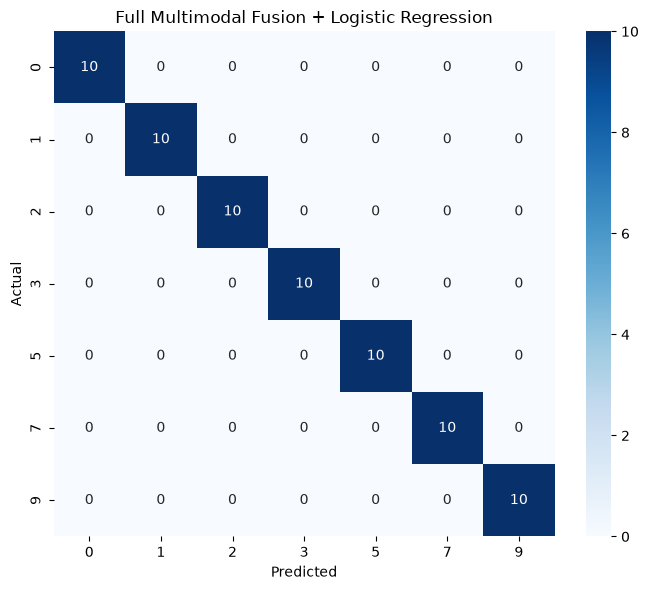

In [395]:
from sklearn.metrics import confusion_matrix

cm_all_lr = confusion_matrix(
    y_test,
    y_all_lr_pred,
    labels=[0, 1, 2, 3, 5, 7, 9]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_all_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0, 1, 2, 3, 5, 7, 9],
    yticklabels=[0, 1, 2, 3, 5, 7, 9]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Full Multimodal Fusion + Logistic Regression")
plt.tight_layout()
plt.show()

## 6.6 Verification of Perfect Classification

The perfect classification result is verified before drawing conclusions.

The verification checks:

1. Train/test sample separation
2. Feature dimensions
3. Absence of target leakage
4. Prediction/test-set alignment
5. Missing or infinite values

This is important because perfect performance can result either from genuinely
strong class separation or from an unintended data-processing issue.

In [396]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current working directory:
c:\Users\Dell\Downloads\Multimodal Dataset for Turmeric Adulteration Detec\notebook

Files/folders here:
['01_dataset_audit.ipynb', '02_exploratory_data_analysis.ipynb', '03_preprocessing.ipynb', '04_baseline_models.ipynb', '05_regression_models.ipynb', '06_modality_comparison_and_fusion.ipynb', 'test_sample_ids.csv', 'train_sample_ids.csv']


In [397]:
import os

for root, dirs, files in os.walk(".."):
    if "train_sample_ids.csv" in files:
        print("FOUND:")
        print(os.path.join(root, "train_sample_ids.csv"))
        break

FOUND:
..\notebook\train_sample_ids.csv


In [398]:
import os
import numpy as np
import pandas as pd

# Preprocessed files are located in the current notebook folder
preprocessed_dir = "."

train_ids = pd.read_csv(
    os.path.join(preprocessed_dir, "train_sample_ids.csv")
).squeeze()

test_ids = pd.read_csv(
    os.path.join(preprocessed_dir, "test_sample_ids.csv")
).squeeze()

print("Train/Test Sample-ID overlap:")
print(set(train_ids).intersection(set(test_ids)))

Train/Test Sample-ID overlap:
set()


In [399]:
print("Train samples:", len(train_ids))
print("Test samples:", len(test_ids))

print("Unique train IDs:", train_ids.nunique())
print("Unique test IDs:", test_ids.nunique())

print("Total samples:", len(train_ids) + len(test_ids))

Train samples: 280
Test samples: 70
Unique train IDs: 280
Unique test IDs: 70
Total samples: 350


In [400]:
print("Fusion feature dimensions:")
print()

print("Color + FTIR:")
print("Train:", X_color_ftir_train.shape)
print("Test :", X_color_ftir_test.shape)

print()

print("Color + Image:")
print("Train:", X_color_image_train.shape)
print("Test :", X_color_image_test.shape)

print()

print("FTIR + Image:")
print("Train:", X_ftir_image_train.shape)
print("Test :", X_ftir_image_test.shape)

print()

print("Color + FTIR + Image:")
print("Train:", X_all_train.shape)
print("Test :", X_all_test.shape)

Fusion feature dimensions:

Color + FTIR:
Train: (280, 94)
Test : (70, 94)

Color + Image:
Train: (280, 51)
Test : (70, 51)

FTIR + Image:
Train: (280, 139)
Test : (70, 139)

Color + FTIR + Image:
Train: (280, 142)
Test : (70, 142)


In [401]:
print("NaN values:")
print()

print("Color + FTIR:",
      np.isnan(X_color_ftir_train).sum())

print("Color + Image:",
      np.isnan(X_color_image_train).sum())

print("FTIR + Image:",
      np.isnan(X_ftir_image_train).sum())

print("Full Fusion:",
      np.isnan(X_all_train).sum())

NaN values:

Color + FTIR: 0
Color + Image: 0
FTIR + Image: 0
Full Fusion: 0


In [402]:
print("Infinite values:")
print()

print("Color + FTIR:",
      np.isinf(X_color_ftir_train).sum())

print("Color + Image:",
      np.isinf(X_color_image_train).sum())

print("FTIR + Image:",
      np.isinf(X_ftir_image_train).sum())

print("Full Fusion:",
      np.isinf(X_all_train).sum())

Infinite values:

Color + FTIR: 0
Color + Image: 0
FTIR + Image: 0
Full Fusion: 0


In [403]:
print("Prediction/Test Alignment")
print()

print("Test samples:", len(y_test))
print("Predictions:", len(y_all_lr_pred))

correct_predictions = np.sum(
    y_test.values == y_all_lr_pred
)

incorrect_predictions = np.sum(
    y_test.values != y_all_lr_pred
)

print("Correct predictions:", correct_predictions)
print("Incorrect predictions:", incorrect_predictions)

Prediction/Test Alignment

Test samples: 70
Predictions: 70
Correct predictions: 70
Incorrect predictions: 0


In [404]:
print("Test-set class distribution:")
print(
    pd.Series(y_test)
    .value_counts()
    .sort_index()
)

Test-set class distribution:
Adulteration_Percent
0.0    10
1.0    10
2.0    10
3.0    10
5.0    10
7.0    10
9.0    10
Name: count, dtype: int64


In [405]:
print("Full Fusion Numerical Sanity Check:")
print()

sanity_check = pd.DataFrame(X_all_train).describe().loc[
    ["mean", "std", "min", "max"]
]

print(sanity_check.iloc[:, :10])

Full Fusion Numerical Sanity Check:

                 0         1             2             3             4  \
mean  4.060244e-16  0.000000  4.440892e-17 -8.120488e-16 -4.060244e-16   
std   6.498005e+00  1.800490  6.685008e-01  3.413401e+01  1.306945e+01   
min  -1.386611e+01 -4.872097 -2.386284e+00 -4.658829e+01 -3.397294e+01   
max   1.025504e+01  4.357956  1.158368e+00  6.831603e+01  1.356965e+01   

              5             6             7             8             9  
mean   0.000000  1.015061e-16  1.966681e-16  1.490871e-16 -6.661338e-17  
std    8.643402  6.184449e+00  4.648213e+00  4.524384e+00  4.485469e+00  
min  -11.278979 -8.582563e+00 -2.588121e+01 -2.272014e+01 -2.143529e+01  
max   18.454998  1.348892e+01  2.143014e+01  3.837061e+01  3.084677e+01  


In [406]:
target_values = set(y_train.astype(float).unique())

print("Target classes:")
print(sorted(target_values))

print("\nChecking whether any full-fusion feature column exactly matches the target...")

matching_columns = []

for i in range(X_all_train.shape[1]):
    feature_column = X_all_train[:, i]

    if np.allclose(feature_column, y_train.values):
        matching_columns.append(i)

print("Matching feature columns:", matching_columns)

Target classes:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(9.0)]

Checking whether any full-fusion feature column exactly matches the target...
Matching feature columns: []


In [407]:
overlap = set(train_ids).intersection(set(test_ids))

checks = {
    "Train/Test overlap = 0": len(overlap) == 0,
    "Train samples = 280": len(train_ids) == 280,
    "Test samples = 70": len(test_ids) == 70,
    "Train IDs unique": train_ids.nunique() == 280,
    "Test IDs unique": test_ids.nunique() == 70,
    "Full fusion train shape correct": X_all_train.shape == (280, 142),
    "Full fusion test shape correct": X_all_test.shape == (70, 142),
    "No NaN values": np.isnan(X_all_train).sum() == 0,
    "No infinite values": np.isinf(X_all_train).sum() == 0,
    "Prediction count = test count": len(y_all_lr_pred) == len(y_test),
    "70/70 predictions correct": np.sum(y_test.values == y_all_lr_pred) == 70,
    "No direct target feature": len(matching_columns) == 0
}

print("Verification Summary")
print("=" * 40)

for check, result in checks.items():
    print(f"{check}: {'PASS' if result else 'FAIL'}")

Verification Summary
Train/Test overlap = 0: PASS
Train samples = 280: PASS
Test samples = 70: PASS
Train IDs unique: PASS
Test IDs unique: PASS
Full fusion train shape correct: PASS
Full fusion test shape correct: PASS
No NaN values: PASS
No infinite values: PASS
Prediction count = test count: PASS
70/70 predictions correct: PASS
No direct target feature: PASS


## 7. Fusion Classification Comparison

Different classifiers are evaluated on the fused multimodal representations.

The following fusion combinations are compared:

1. Color + FTIR
2. Color + Image
3. FTIR + Image
4. Color + FTIR + Image

For each fusion representation, Logistic Regression, SVM (RBF), and Random Forest
are evaluated using the same fixed train/test split.

This helps determine whether the observed performance is consistent across
different learning algorithms.

In [408]:
fusion_svm_results = []

fusion_datasets = {
    "Color + FTIR": (
        X_color_ftir_train,
        X_color_ftir_test
    ),
    "Color + Image": (
        X_color_image_train,
        X_color_image_test
    ),
    "FTIR + Image": (
        X_ftir_image_train,
        X_ftir_image_test
    ),
    "Color + FTIR + Image": (
        X_all_train,
        X_all_test
    )
}

for name, (X_train_fusion, X_test_fusion) in fusion_datasets.items():

    svm_model = SVC(
        kernel="rbf",
        random_state=42
    )

    svm_model.fit(X_train_fusion, y_train)

    y_pred = svm_model.predict(X_test_fusion)

    fusion_svm_results.append({
        "Fusion": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro Precision": precision_score(
            y_test, y_pred, average="macro"
        ),
        "Macro Recall": recall_score(
            y_test, y_pred, average="macro"
        ),
        "Macro F1": f1_score(
            y_test, y_pred, average="macro"
        )
    })

fusion_svm_results_df = pd.DataFrame(fusion_svm_results)

fusion_svm_results_df

,Fusion,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Color + FTIR,1.0,1.0,1.0,1.0
1,Color + Image,1.0,1.0,1.0,1.0
2,FTIR + Image,1.0,1.0,1.0,1.0
3,Color + FTIR + Image,1.0,1.0,1.0,1.0


In [409]:
fusion_rf_results = []

for name, (X_train_fusion, X_test_fusion) in fusion_datasets.items():

    rf_model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train_fusion, y_train)

    y_pred = rf_model.predict(X_test_fusion)

    fusion_rf_results.append({
        "Fusion": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro Precision": precision_score(
            y_test, y_pred, average="macro"
        ),
        "Macro Recall": recall_score(
            y_test, y_pred, average="macro"
        ),
        "Macro F1": f1_score(
            y_test, y_pred, average="macro"
        )
    })

fusion_rf_results_df = pd.DataFrame(fusion_rf_results)

fusion_rf_results_df

,Fusion,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Color + FTIR,1.000000,1.000000,1.000000,1.000000
1,Color + Image,0.971429,0.974026,0.971429,0.971357
2,FTIR + Image,1.000000,1.000000,1.000000,1.000000
3,Color + FTIR + Image,1.000000,1.000000,1.000000,1.000000


In [410]:
fusion_lr_results_df = pd.DataFrame(fusion_lr_results)

fusion_lr_results_df["Model"] = "Logistic Regression"
fusion_svm_results_df["Model"] = "SVM (RBF)"
fusion_rf_results_df["Model"] = "Random Forest"

fusion_comparison = pd.concat(
    [
        fusion_lr_results_df,
        fusion_svm_results_df,
        fusion_rf_results_df
    ],
    ignore_index=True
)

fusion_comparison = fusion_comparison[
    [
        "Fusion",
        "Model",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
]

fusion_comparison.sort_values(
    ["Fusion", "Model"]
).reset_index(drop=True)

,Fusion,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Color + FTIR,Random Forest,1.000000,1.000000,1.000000,1.000000
1,Color + FTIR,SVM (RBF),1.000000,1.000000,1.000000,1.000000
2,Color + FTIR + Image,Random Forest,1.000000,1.000000,1.000000,1.000000
3,Color + FTIR + Image,SVM (RBF),1.000000,1.000000,1.000000,1.000000
4,Color + Image,Random Forest,0.971429,0.974026,0.971429,0.971357
5,Color + Image,SVM (RBF),1.000000,1.000000,1.000000,1.000000
6,FTIR + Image,Random Forest,1.000000,1.000000,1.000000,1.000000
7,FTIR + Image,SVM (RBF),1.000000,1.000000,1.000000,1.000000


## 7.5 Fusion Confusion Matrices

Confusion matrices are used to examine class-level predictions for the fusion models.

The matrices show whether errors occur between nearby adulteration levels or across
more distant classes.

This is particularly important because the dataset contains ordered adulteration
levels: 0%, 1%, 2%, 3%, 5%, 7%, and 9%.

In [411]:
from sklearn.metrics import confusion_matrix

# Store the predictions from the three models
fusion_predictions = {}

# Logistic Regression
fusion_predictions["Color + FTIR — LR"] = y_color_ftir_lr_pred
fusion_predictions["Color + Image — LR"] = y_color_image_lr_pred
fusion_predictions["FTIR + Image — LR"] = y_ftir_image_lr_pred
fusion_predictions["All — LR"] = y_all_lr_pred

# SVM predictions
for name, (X_train_fusion, X_test_fusion) in fusion_datasets.items():

    svm_model = SVC(
        kernel="rbf",
        random_state=42
    )

    svm_model.fit(X_train_fusion, y_train)

    fusion_predictions[f"{name} — SVM"] = svm_model.predict(
        X_test_fusion
    )

# Random Forest predictions
for name, (X_train_fusion, X_test_fusion) in fusion_datasets.items():

    rf_model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train_fusion, y_train)

    fusion_predictions[f"{name} — RF"] = rf_model.predict(
        X_test_fusion
    )

In [412]:
rf_color_image_cm = confusion_matrix(
    y_test,
    fusion_predictions["Color + Image — RF"],
    labels=[0, 1, 2, 3, 5, 7, 9]
)

print(rf_color_image_cm)

[[10  0  0  0  0  0  0]
 [ 1  9  0  0  0  0  0]
 [ 0  0  9  1  0  0  0]
 [ 0  0  0 10  0  0  0]
 [ 0  0  0  0 10  0  0]
 [ 0  0  0  0  0 10  0]
 [ 0  0  0  0  0  0 10]]


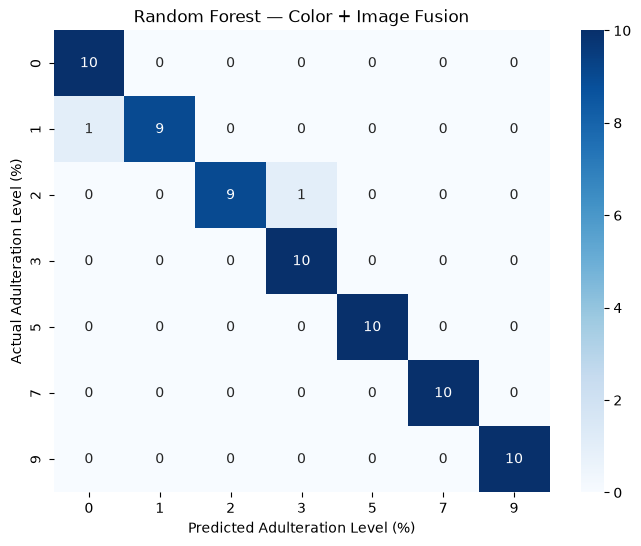

In [413]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    rf_color_image_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0, 1, 2, 3, 5, 7, 9],
    yticklabels=[0, 1, 2, 3, 5, 7, 9]
)

plt.xlabel("Predicted Adulteration Level (%)")
plt.ylabel("Actual Adulteration Level (%)")
plt.title("Random Forest — Color + Image Fusion")
plt.show()

## 8. Fusion Regression

The classification experiments predict discrete adulteration levels.

In this section, the problem is treated as regression, where the model predicts
the numerical adulteration percentage.

The following fusion representations are evaluated:

1. Color + FTIR
2. Color + Image
3. FTIR + Image
4. Color + FTIR + Image

Models evaluated:

- Linear Regression
- Support Vector Regression (RBF)
- Random Forest Regression

Performance is measured using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² score

The same fixed train/test split is used for all experiments.

In [414]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

fusion_regression_results = []

# Convert target to numerical arrays
y_train_reg = y_train.astype(float).values
y_test_reg = y_test.astype(float).values

for name, (X_train_fusion, X_test_fusion) in fusion_datasets.items():

    # -------------------------
    # Linear Regression
    # -------------------------
    lr_model = LinearRegression()

    lr_model.fit(
        X_train_fusion,
        y_train_reg
    )

    y_pred_lr = lr_model.predict(
        X_test_fusion
    )

    fusion_regression_results.append({
        "Fusion": name,
        "Model": "Linear Regression",
        "MAE": mean_absolute_error(y_test_reg, y_pred_lr),
        "RMSE": np.sqrt(
            mean_squared_error(y_test_reg, y_pred_lr)
        ),
        "R²": r2_score(y_test_reg, y_pred_lr)
    })

    # -------------------------
    # SVR
    # -------------------------
    svr_model = SVR(
        kernel="rbf"
    )

    svr_model.fit(
        X_train_fusion,
        y_train_reg
    )

    y_pred_svr = svr_model.predict(
        X_test_fusion
    )

    fusion_regression_results.append({
        "Fusion": name,
        "Model": "SVR (RBF)",
        "MAE": mean_absolute_error(y_test_reg, y_pred_svr),
        "RMSE": np.sqrt(
            mean_squared_error(y_test_reg, y_pred_svr)
        ),
        "R²": r2_score(y_test_reg, y_pred_svr)
    })

    # -------------------------
    # Random Forest Regression
    # -------------------------
    rf_model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(
        X_train_fusion,
        y_train_reg
    )

    y_pred_rf = rf_model.predict(
        X_test_fusion
    )

    fusion_regression_results.append({
        "Fusion": name,
        "Model": "Random Forest",
        "MAE": mean_absolute_error(y_test_reg, y_pred_rf),
        "RMSE": np.sqrt(
            mean_squared_error(y_test_reg, y_pred_rf)
        ),
        "R²": r2_score(y_test_reg, y_pred_rf)
    })

fusion_regression_df = pd.DataFrame(
    fusion_regression_results
)

fusion_regression_df

,Fusion,Model,MAE,RMSE,R²
0,Color + FTIR,Linear Regression,0.214505,0.268118,0.992241
1,Color + FTIR,SVR (RBF),0.359543,0.527336,0.969987
2,Color + FTIR,Random Forest,0.013524,0.031259,0.999895
3,Color + Image,Linear Regression,0.540802,0.653919,0.953848
4,Color + Image,SVR (RBF),0.710564,1.027687,0.886011
5,Color + Image,Random Forest,0.230714,0.514838,0.971392
6,FTIR + Image,Linear Regression,0.228485,0.285288,0.991216
7,FTIR + Image,SVR (RBF),0.474607,0.614831,0.959201
8,FTIR + Image,Random Forest,0.013810,0.031552,0.999893
9,Color + FTIR + Image,Linear Regression,0.216807,0.271605,0.992038


## 8.5 Fusion Regression Residual Analysis

Residual analysis is performed for the strongest fusion regression models.

The residual is calculated as:

Actual adulteration percentage − Predicted adulteration percentage

The analysis examines:

- prediction accuracy across adulteration levels
- residual distribution
- whether errors are concentrated at particular levels
- whether the model systematically overestimates or underestimates certain levels

These results are interpreted only for the fixed test set.

In [415]:
# Color + FTIR Random Forest
rf_color_ftir = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_color_ftir.fit(
    X_color_ftir_train,
    y_train_reg
)

y_pred_color_ftir = rf_color_ftir.predict(
    X_color_ftir_test
)


# FTIR + Image Random Forest
rf_ftir_image = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_ftir_image.fit(
    X_ftir_image_train,
    y_train_reg
)

y_pred_ftir_image = rf_ftir_image.predict(
    X_ftir_image_test
)

In [416]:
comparison_df = pd.DataFrame({
    "Actual": y_test_reg,
    "Color + FTIR Prediction": y_pred_color_ftir,
    "FTIR + Image Prediction": y_pred_ftir_image
})

comparison_df.head(15)

,Actual,Color + FTIR Prediction,FTIR + Image Prediction
0,0.0,0.000000,0.003333
1,0.0,0.003333,0.000000
2,0.0,0.000000,0.000000
3,0.0,0.000000,0.000000
4,0.0,0.080000,0.090000
5,0.0,0.140000,0.143333
6,0.0,0.060000,0.070000
7,0.0,0.000000,0.000000
8,0.0,0.016667,0.020000
9,0.0,0.096667,0.100000


In [417]:
comparison_df["Color + FTIR Residual"] = (
    comparison_df["Actual"]
    - comparison_df["Color + FTIR Prediction"]
)

comparison_df["FTIR + Image Residual"] = (
    comparison_df["Actual"]
    - comparison_df["FTIR + Image Prediction"]
)

comparison_df.head(15)

,Actual,Color + FTIR Prediction,FTIR + Image Prediction,Color + FTIR Residual,FTIR + Image Residual
0,0.0,0.000000,0.003333,0.000000,-0.003333
1,0.0,0.003333,0.000000,-0.003333,0.000000
2,0.0,0.000000,0.000000,0.000000,0.000000
3,0.0,0.000000,0.000000,0.000000,0.000000
4,0.0,0.080000,0.090000,-0.080000,-0.090000
5,0.0,0.140000,0.143333,-0.140000,-0.143333
6,0.0,0.060000,0.070000,-0.060000,-0.070000
7,0.0,0.000000,0.000000,0.000000,0.000000
8,0.0,0.016667,0.020000,-0.016667,-0.020000
9,0.0,0.096667,0.100000,-0.096667,-0.100000


In [418]:
error_by_level = comparison_df.groupby("Actual").agg(
    Color_FTIR_MAE=(
        "Color + FTIR Residual",
        lambda x: np.mean(np.abs(x))
    ),
    FTIR_Image_MAE=(
        "FTIR + Image Residual",
        lambda x: np.mean(np.abs(x))
    ),
    Samples=("Actual", "count")
).reset_index()

error_by_level

,Actual,Color_FTIR_MAE,FTIR_Image_MAE,Samples
0,0.0,0.039667,0.042667,10
1,1.0,0.015000,0.015333,10
2,2.0,0.022333,0.019333,10
3,3.0,0.007667,0.011333,10
4,5.0,0.000000,0.004000,10
5,7.0,0.006667,0.002667,10
6,9.0,0.003333,0.001333,10


## 8.6 Actual vs Predicted Adulteration

Actual and predicted adulteration percentages are compared for the strongest
fusion regression models.

A close alignment with the ideal prediction line indicates accurate estimation
of adulteration percentage on the fixed test set.

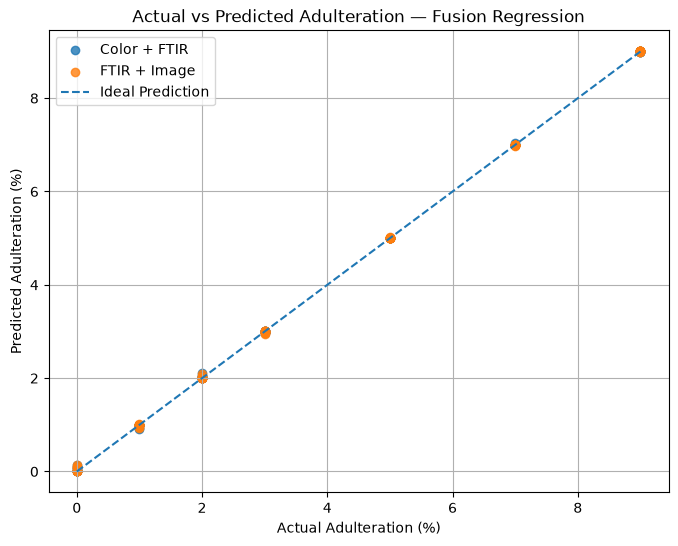

In [419]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_reg,
    y_pred_color_ftir,
    alpha=0.8,
    label="Color + FTIR"
)

plt.scatter(
    y_test_reg,
    y_pred_ftir_image,
    alpha=0.8,
    label="FTIR + Image"
)

min_value = min(
    y_test_reg.min(),
    y_pred_color_ftir.min(),
    y_pred_ftir_image.min()
)

max_value = max(
    y_test_reg.max(),
    y_pred_color_ftir.max(),
    y_pred_ftir_image.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Ideal Prediction"
)

plt.xlabel("Actual Adulteration (%)")
plt.ylabel("Predicted Adulteration (%)")
plt.title("Actual vs Predicted Adulteration — Fusion Regression")
plt.legend()
plt.grid(True)
plt.show()

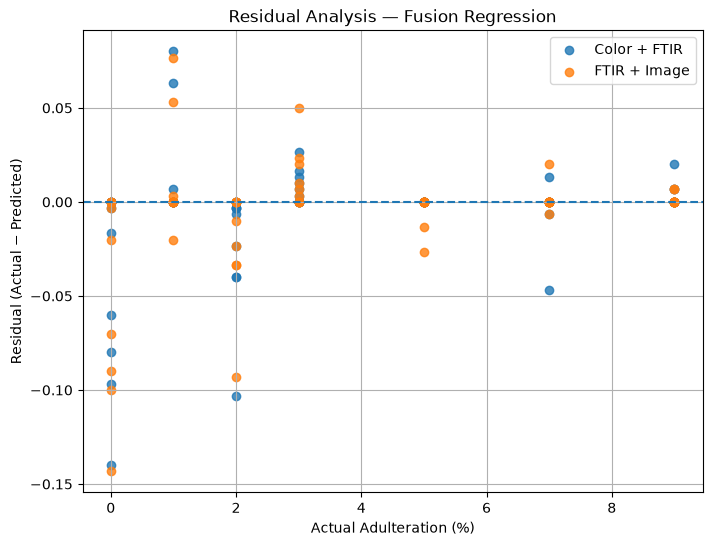

In [420]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_reg,
    comparison_df["Color + FTIR Residual"],
    alpha=0.8,
    label="Color + FTIR"
)

plt.scatter(
    y_test_reg,
    comparison_df["FTIR + Image Residual"],
    alpha=0.8,
    label="FTIR + Image"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Actual Adulteration (%)")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Residual Analysis — Fusion Regression")
plt.legend()
plt.grid(True)
plt.show()

## 9. Overall Modality and Fusion Analysis

This section summarizes the classification and regression experiments across
individual modalities and multimodal fusion strategies.

The analysis considers:

- Color
- FTIR
- EfficientNet-B0 image features
- Color + FTIR
- Color + Image
- FTIR + Image
- Color + FTIR + Image

Both classification and regression results are considered.

The objective is to understand:

1. which modalities contain useful information for adulteration detection
2. whether combining modalities improves performance
3. whether additional modalities consistently improve performance
4. which fusion representations are effective for classification and quantification

In [421]:
classification_summary = fusion_comparison.copy()

classification_summary

classification_summary[
    ["Fusion", "Model", "Accuracy", "Macro Precision",
     "Macro Recall", "Macro F1"]
].round(4)

regression_summary = fusion_regression_df.copy()

regression_summary[
    ["Fusion", "Model", "MAE", "RMSE", "R²"]
].round(4)

overall_summary = fusion_regression_df.copy()

overall_summary["MAE"] = overall_summary["MAE"].round(4)
overall_summary["RMSE"] = overall_summary["RMSE"].round(4)
overall_summary["R²"] = overall_summary["R²"].round(4)

overall_summary

,Fusion,Model,MAE,RMSE,R²
0,Color + FTIR,Linear Regression,0.2145,0.2681,0.9922
1,Color + FTIR,SVR (RBF),0.3595,0.5273,0.9700
2,Color + FTIR,Random Forest,0.0135,0.0313,0.9999
3,Color + Image,Linear Regression,0.5408,0.6539,0.9538
4,Color + Image,SVR (RBF),0.7106,1.0277,0.8860
5,Color + Image,Random Forest,0.2307,0.5148,0.9714
6,FTIR + Image,Linear Regression,0.2285,0.2853,0.9912
7,FTIR + Image,SVR (RBF),0.4746,0.6148,0.9592
8,FTIR + Image,Random Forest,0.0138,0.0316,0.9999
9,Color + FTIR + Image,Linear Regression,0.2168,0.2716,0.9920


## 10. Conclusion

The modality comparison and fusion experiments investigated whether combining
Color, FTIR spectroscopy, and EfficientNet-B0 image representations improves
turmeric adulteration detection and quantification.

### Classification

All four fusion representations achieved very high classification performance
on the fixed 70-sample test set. Logistic Regression and SVM achieved perfect
classification across the evaluated fusion combinations. Random Forest also
achieved perfect classification for Color + FTIR, FTIR + Image, and full fusion,
while Color + Image achieved 97.14% accuracy.

For the Color + Image Random Forest model, the two classification errors occurred
between neighboring low-level adulteration classes: 1% was predicted as 0% and
2% was predicted as 3%.

### Regression

Random Forest produced extremely low regression errors for fusion combinations
containing FTIR. Color + FTIR achieved an MAE of approximately 0.0135 percentage
points and an R² of approximately 0.9999 on the fixed test set.

FTIR + Image produced a similar result, while full three-modality fusion showed
a slightly higher MAE than Color + FTIR.

This indicates that adding more modalities does not automatically improve
performance. The usefulness of a fusion strategy depends on the information
provided by each modality and the learning algorithm.

### Modality-Level Observation

FTIR appears to provide particularly strong information for adulteration
quantification in this controlled dataset. Color measurements also contain useful
information, while the EfficientNet-B0 image representation contributes useful
information but does not consistently improve regression when added to FTIR.

### Important Limitation

The reported results are obtained from a controlled dataset and a single fixed
sample-level train/test split containing 350 samples.

The extremely high performance should therefore not be interpreted as guaranteed
real-world performance.

Further validation using independent physical samples, repeated cross-validation,
and external datasets is required to assess generalization.

### Research Prototype Interpretation

The results support the feasibility of an AI-assisted research prototype for
turmeric adulteration screening and estimation using multimodal data.

Laboratory verification remains recommended before practical deployment.

-----------------------------------------------------------------------------